<h1 style="font-size:36px; color:black; text-align:center; margin-bottom:15px;">
    Trajectory Analysis of Rolling Modular Robot
</h1>

<p style="font-size:20px; text-align:center; line-height:1.6;">
    Offir Olivkovich<br>
    Bachelor's Thesis, Radboud University<br>
    Supervised by Dr. M.Y. Ben Zion 
    (<a href="https://www.mybz.org/" target="_blank" style="color:#1a73e8; text-decoration:none;">Artificial Swarm Intelligence Lab</a>)
</p>
<hr style="height:2px; border:none; background:#333; margin: 30px 0;">


<div style="font-size:18px; padding:20px; margin-top:10px;">
This analysis forms part of a bachelor's thesis on designing a modular rolling robot whose 
behavior emerges from its mechanical configuration rather than onboard computation. 
The central question is whether simple physical changes—such as mass placement and wheel 
orientation—can consistently encode directional tendencies relative to external forces.
</div>

<div style="font-size:18px; background-color:#a7dbb3; display:inline-block; padding:15px 20px; margin:30px; margin-top:-10px; border-radius:6px;">
To evaluate this principle, we examine the robot’s real-world motion across different 
mechanical configurations on flat and inclined surfaces. The analysis quantifies how 
these configurations influence path shape, displacement, velocity profiles, and 
directional bias.
</div>

<h2 style="margin-top:25px;">Outputs Produced</h2>

<ul style="font-size:16px; line-height:1.6;">
  <li><code>data/trajectories/all_trials.csv</code> — reconstructed trajectories with trial metadata.</li>
  <li><code>data/features/features.csv</code> — quantitative features computed per trial.</li>
  <li><code>group_summary_flat</code> and <code>group_summary_incline</code> — aggregated statistics by configuration.</li>
  <li>Figures: trajectory visualizations and feature distributions for all conditions.</li>
</ul>


<div style="font-size:18px; padding:20px; line-height:2.5">
    <h3>Table of Contents</h3>
    <a href="#1">1. Environment Setup</a><br>
    <a href="#2">2. Motion Tracking and Trajectory Reconstruction</a><br>
    <a href="#3">3. Trial Segmentation and Condition Mapping</a><br>
    <!-- <a href="#3.1"> 3.1</a><br> -->
    <!-- <a href="#3.2"> 3.2</a><br> -->
    <a href="#4">4. Feature Extraction and Quantitative Metrics</a><br>
    <a href="#5">5. Conclusion</a>
</div>

<h1>1. Environment Setup <a id="1"></a></h1>

<p style="font-size:18px; line-height:1.6;">
Define global configuration parameters (fps, scale, file locations) and load all required Python packages.
</p>

<p style="font-size:18px; line-height:1.6;">
Import custom helper modules from the <code>../code/</code> directory:
</p>

<ul style="font-size:18px; line-height:1.5;">
    <li><code>extract_trajectory.py</code>: handles video tracking and bounding-box extraction</li>
    <li><code>compute_features.py</code>: computes trial-level kinematic features</li>
    <li><code>estimate_kappa.py</code>: curvature estimation utilities</li>
</ul>

<p style="font-size:18px; line-height:1.6;">
The <code>%autoreload</code> extension is enabled so that changes to these modules update automatically.
</p>


In [1]:
# global configuration parameters (fps, scale, file locations)
USE_SAVED = True
FPS = 60
SCALE = 0.17

TRAJECTORY_PATH = "../data/trajectories/all_trials.csv"
FEATURE_PATH = "../data/features/features.csv"

# imports
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# helper modules
%load_ext autoreload
%autoreload 2
    
sys.path.append("../code")

from extract_trajectory import select_bbox, process_folder
from compute_features import summarize_all_trials
from estimate_kappa import estimate_kappa_gridsearch, estimate_kappa_from_heading

<h1>2. Motion Tracking and Trajectory Reconstruction <a id="2"></a></h1>

<p style="font-size:18px; line-height:1.6;">
Extract x–y trajectories from raw experiment videos or load existing trajectory data.
</p>

<ul style="font-size:18px; line-height:1.6;">
    <li><code>use_saved = True</code>: Load a precomputed trajectory table</li>
    <li><code>use_saved = False</code>: Track trajectories directly from the raw videos</li>
</ul>

<p style="font-size:18px; line-height:1.6;">
The tracking pipeline performs:
</p>

<ol style="font-size:18px; line-height:1.6;" margin-left:20px;">
    <li>Bounding-box selection for the region of interest</li>
    <li>Per-frame detection of the robot</li>
    <li>Smoothing and trial segmentation</li>
    <li>Attaching metadata:
        <ul style="margin-top:5px;">
            <li><code>condition</code> (Flat / Incline)</li>
            <li><code>orientation</code> (Wheel orientation or starting side)</li>
            <li><code>position</code> (Front or rear weighting of the mass block)</li>
        </ul>
    </li>
</ol>

<p style="font-size:18px; line-height:1.6;">
The resulting dataframe (<code>all_traj</code>) contains one row per frame.
</p>


In [2]:
# load OR track
if USE_SAVED and os.path.exists(TRAJECTORY_PATH):
    print("loading saved trajectory data...")
    all_traj = pd.read_csv(TRAJECTORY_PATH)
    print("loaded:", all_traj.shape)
else:
    print("tracking videos...")
    base_video_dir = "../data/videos"
    all_dataframes = []

    for condition in ["flat", "incline"]:
        condition_path = os.path.join(base_video_dir, condition)
        for orientation in os.listdir(condition_path):
            if orientation.startswith("."):
                continue
            folder = os.path.join(condition_path, orientation)
            if not os.path.isdir(folder):
                continue

            print(f"tracking: {folder}")
            try:
                bbox = select_bbox(folder, label=f"{condition}-{orientation}")
                if bbox == (0, 0, 0, 0):
                    raise ValueError("empty roi selected")
            except Exception as e:
                print(f"skipping {folder} — error: {e}")
                continue

            df = process_folder(folder, bbox)
            if not df.empty:
                df["condition"] = condition          # flat / incline
                df["orientation"] = orientation       # wheels or side, depending on condition
                all_dataframes.append(df)

    if all_dataframes:
        all_traj = pd.concat(all_dataframes, ignore_index=True)
        os.makedirs(os.path.dirname(TRAJECTORY_PATH), exist_ok=True)
        all_traj.to_csv(TRAJECTORY_PATH, index=False)
        print("saved:", TRAJECTORY_PATH)
    else:
        raise RuntimeError("no trajectory data collected")
all_traj.head()

loading saved trajectory data...
loaded: (35501, 7)


,trial,position,orientation,frame,x,y,condition
0,flipped_back (1),back,flipped,0,1810.0,543.0,flat
1,flipped_back (1),back,flipped,1,1810.0,543.0,flat
2,flipped_back (1),back,flipped,2,1810.0,543.0,flat
3,flipped_back (1),back,flipped,3,1810.0,544.0,flat
4,flipped_back (1),back,flipped,4,1811.0,544.0,flat


<h4>Visualize</h4>

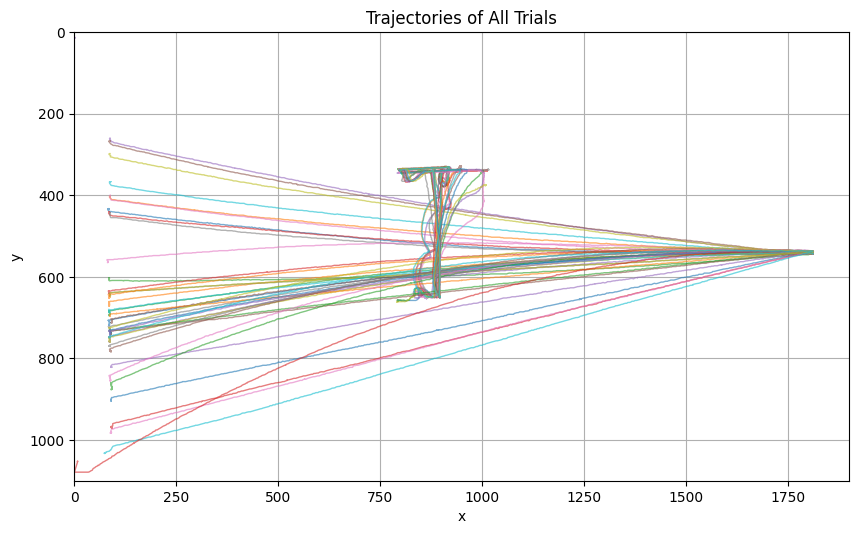

In [3]:
plt.figure(figsize=(10, 8))

for trial_id, trial_df in all_traj.groupby("trial"):
    plt.plot(trial_df["x"], trial_df["y"], alpha=0.6, linewidth=1)

plt.title("Trajectories of All Trials")
plt.xlim(0, 1900)
plt.ylim(0, 1100)
plt.gca().invert_yaxis()
plt.gca().set_aspect("equal")
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")

plt.show()

<h1>3. Trial Segmentation and Condition Mapping<a id="3"></a></h1>

<p style="font-size:18px; line-height:1.6;">
Separate trajectories into:
</p>

<ul style="font-size:18px; line-height:1.6;">
    <li><a href="#3.1"> Flat condition - </a><code>flat_traj</code>: first stage where seu rolls on a flat surface</li>
    <li><a href="#3.2"> Incline condition - </a><code>incline_traj</code>: second stage where seu rolls on a fixed incline</li>
</ul>

In [4]:
# split flat vs incline
flat_df = all_traj[all_traj["condition"] == "flat"].copy()
incline_df = all_traj[all_traj["condition"] == "incline"].copy()

<h3>3.1. Visualize both Conditions<a id="3.1"></a></h3>

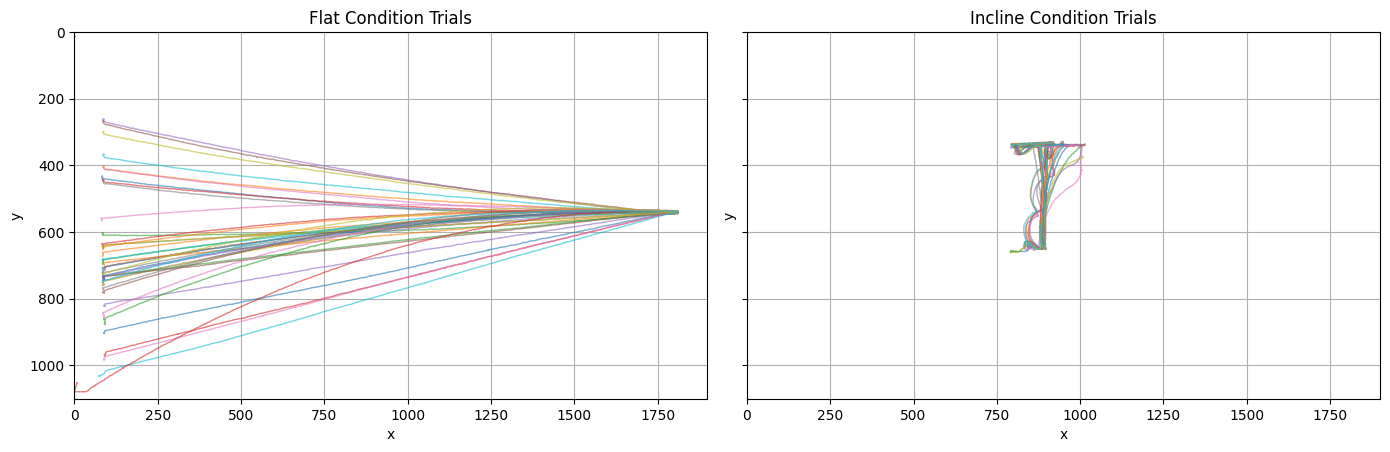

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

dfs = [flat_df, incline_df]
titles = ["Flat Condition Trials", "Incline Condition Trials"]

for ax, df, title in zip(axes, dfs, titles):
    # plot each trial
    for trial_id, trial_df in df.groupby("trial"):
        ax.plot(trial_df["x"], trial_df["y"], alpha=0.6, linewidth=1)

    ax.set_title(title)
    ax.set_xlim(0, 1900)
    ax.set_ylim(0, 1100)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.grid(True)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

<h4>Label Dictionaries</h4>

<p style="font-size:14px; line-height:1.6;">
The label dictionaries below define how each trial’s physical setup is described in the analysis.
They map the raw condition codes in the data to clearer, human-readable labels that reflect how
the robot was configured during the experiment:
</p>

<ul style="font-size:14px; line-height:1.6; margin-left:20px;">
    <li><b>Mass position</b>: whether the added weight is placed at the <b>front</b> or <b>rear</b> of the robot.</li>
    <li><b>Wheel orientation</b>: whether the wheels are mounted in the <b>normal</b> or <b>flipped</b> direction.</li>
    <li><b>Starting side</b> (incline trials): whether the robot begins the run on the <b>left</b> or <b>right</b> side of the incline.</li>
</ul>

<p style="font-size:14px; line-height:1.6;">
These mappings keep all figures and summaries readable and consistent across trials.
</p>


In [6]:
# define label dictionaries
mass_label = {
    "front": "mass: front",
    "back": "mass: rear",
}

wheel_label = {
    "normal": "wheels: normal",
    "flipped": "wheels: flipped",
}

side_label = {
    "left": "starts: left",
    "right": "starts: right",
}

<h3>3.2. Visualize Flat Condition<a id="3.2"></a></h3>

<p style="font-size:18px; line-height:1.6;">
To understand how the robot behaves under different mechanical setups, we visualize the trajectories
in three complementary ways. First, we show all four configurations (mass × wheels) in a single 2×2
grid. Then, we isolate each factor by grouping the trajectories once by mass position and once by
wheel orientation.
</p>



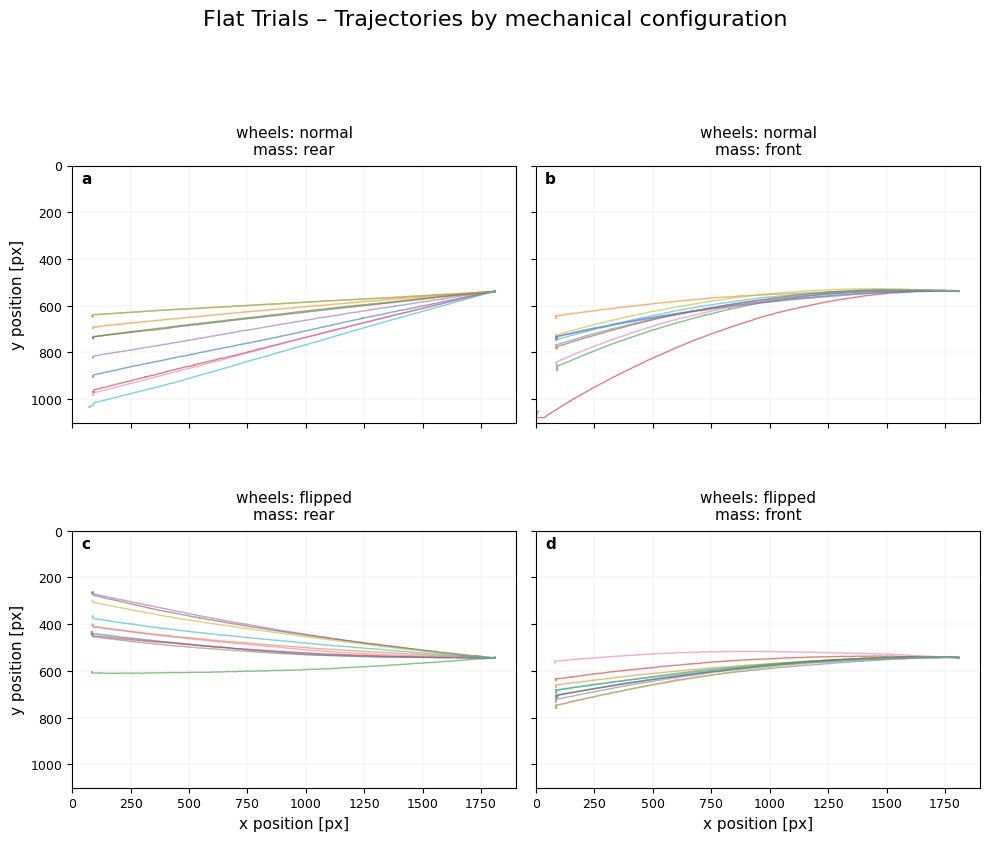

In [7]:
# flat condition: 2x2 grid by wheel orientation and mass position

fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
axes = axes.flatten()

fig.suptitle(
    "Flat Trials – Trajectories by mechanical configuration",
    fontsize=16,
    y=0.97,
)

groups = flat_df.groupby(["orientation", "position"])

# consistent order (same as before)
keys = [
    ("normal", "back"),
    ("normal", "front"),
    ("flipped", "back"),
    ("flipped", "front"),
]

# optional panel labels (a, b, c, d)
panel_labels = ["a", "b", "c", "d"]

for ax, key, panel_label in zip(axes, keys, panel_labels):
    orientation, position = key
    label_w = wheel_label[orientation]   # e.g. "wheels: normal"
    label_m = mass_label[position]       # e.g. "mass: rear"
    group_df = groups.get_group(key)

    # plot all trials for this configuration
    for trial_id, trial_df in group_df.groupby("trial"):
        ax.plot(trial_df["x"], trial_df["y"], alpha=0.6, linewidth=1)

    # nicer two-line title per panel
    ax.set_title(f"{label_w}\n{label_m}", fontsize=11, pad=8)

    # small panel label in the corner (a, b, c, d)
    ax.text(
        0.02, 0.98, panel_label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11, fontweight="bold",
    )

    ax.set_xlim(0, 1900)
    ax.set_ylim(0, 1100)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.grid(True, linewidth=0.3, alpha=0.4)
    ax.tick_params(labelsize=9)

# x labels only on bottom row
for ax in axes[2:]:
    ax.set_xlabel("x position [px]", fontsize=11)

# y labels only on left column
for ax in axes[0::2]:
    ax.set_ylabel("y position [px]", fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


<h3>3.3 Visualize Incline Condition<a id="3.3"></a></h3>

<p style="font-size:18px; line-height:1.6;">
For the incline trials, each run is defined by two physical factors:
</p>

<ul style="font-size:18px; line-height:1.6; margin-left:20px;">
    <li><b>Mass position</b>: additional weight placed at the <b>front</b> or <b>rear</b> of the robot</li>
    <li><b>Starting side</b>: the robot begins on the <b>left</b> or <b>right</b> side of the incline</li>
</ul>

<p style="font-size:18px; line-height:1.6;">
These two variables form a 2×2 set of configurations. We plot each combination in a separate panel:
</p>

<ul style="font-size:18px; line-height:1.6; margin-left:20px;">
    <li>Each curve represents one trial trajectory</li>
    <li>All axes share the same limits and aspect ratio to allow direct comparison</li>
</ul>

<p style="font-size:18px; line-height:1.6; margin-top:10px;">
This matrix view highlights how mass placement and starting side influence the robot’s uphill motion and directional drift on the incline.
</p>


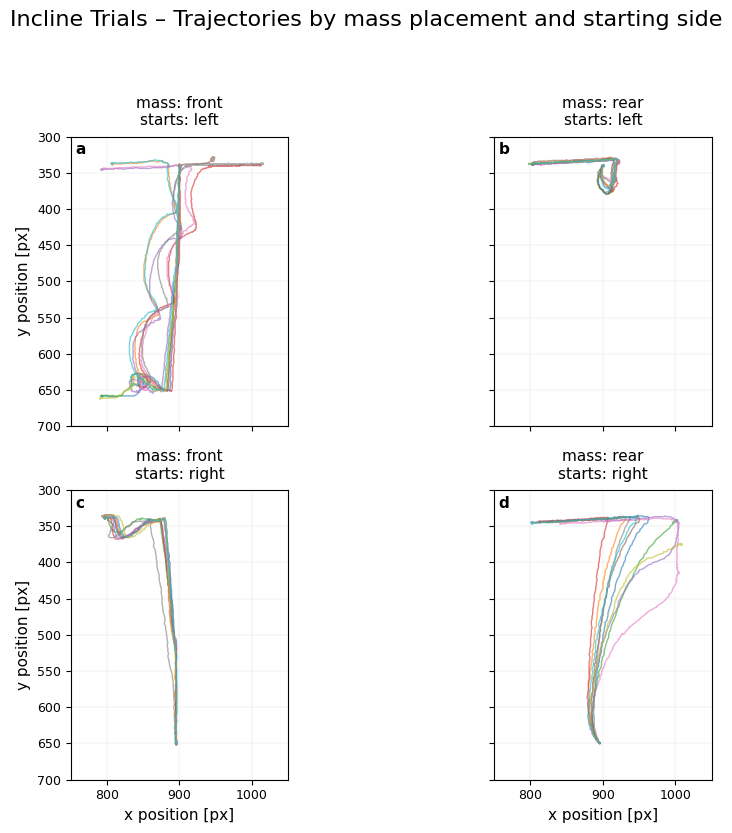

In [8]:
# incline condition: trajectories arranged as a 2×2 matrix (rows = starting side, cols = mass)

groups = incline_df.groupby(["orientation", "position"])
group_keys = sorted(groups.groups.keys())  # e.g. ("left", "front"), ("left", "back"), ...

# define row/col order
side_order = ["left", "right"]
mass_order = ["front", "back"]

fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)

panel_labels = [["a", "b"],
                ["c", "d"]]

for i, side in enumerate(side_order):
    for j, mass in enumerate(mass_order):
        ax = axes[i, j]

        key = (side, mass)
        if key not in groups.groups:
            # if for some reason one combination doesn't exist, hide it
            ax.axis("off")
            continue

        group_df = groups.get_group(key)

        # plot each trial
        for trial_id, trial_df in group_df.groupby("trial"):
            ax.plot(
                trial_df["x"], trial_df["y"],
                alpha=0.6, linewidth=1
            )

        # title on two lines
        ax.set_title(
            f"{mass_label[mass]}\n{side_label[side]}",
            fontsize=11, pad=8
        )

        # panel label
        ax.text(
            0.02, 0.98, panel_labels[i][j],
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=11, fontweight="bold"
        )

        # axis settings
        ax.set_xlim(750, 1050)
        ax.set_ylim(700, 300)
        ax.set_aspect("equal")
        ax.grid(True, linewidth=0.3, alpha=0.4)
        ax.tick_params(labelsize=9)

# global title
fig.suptitle(
    "Incline Trials – Trajectories by mass placement and starting side",
    fontsize=16, y=0.97
)

# shared axis labels
for ax in axes[1, :]:
    ax.set_xlabel("x position [px]", fontsize=11)

for ax in axes[:, 0]:
    ax.set_ylabel("y position [px]", fontsize=11)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.93])
plt.show()


<h1>4. Feature Extraction and Quantitative Metrics <a id="4"></a></h1>

<p style="font-size:18px; line-height:1.6;">
In this step, we reduce each trajectory to a compact set of trial-level features using 
<code>summarize_all_trials()</code>.
</p>

<p style="font-size:18px; line-height:1.6;">
For each trial, we compute:
</p>

<ul style="font-size:18px; line-height:1.6; margin-left:20px;">
    <li>Velocity features (mean and variability)</li>
    <li>Acceleration features (mean, variability, and startup acceleration)</li>
    <li>Displacement and path length</li>
    <li>Directional bias (net x-shift along the incline axis)</li>
    <li>Optional curvature-related summaries</li>
</ul>

<p style="font-size:18px; line-height:1.6;">
The resulting feature table is saved to <code>data/features/features.csv</code> for reuse.
</p>


In [9]:
features_df = summarize_all_trials(all_traj, fps=FPS, scale=SCALE)

os.makedirs(os.path.dirname(FEATURE_PATH), exist_ok=True)
features_df.to_csv(FEATURE_PATH, index=False)

print("features saved:", FEATURE_PATH)
print("feature table shape:", features_df.shape)

feature_specs = [ # for later labeling of plots
    ("mean_velocity_mean", "mean_velocity_std", "mean velocity"),
    ("startup_acceleration_mean", "startup_acceleration_std", "startup acceleration"),
    ("displacement_mean", "displacement_std", "displacement"),
    ("directional_bias_mean", "directional_bias_std", "directional bias"),
]

features_df.head()

features saved: ../data/features/features.csv
feature table shape: (80, 10)


,trial,position,orientation,mean_velocity,std_velocity,mean_acceleration,std_acceleration,startup_acceleration,displacement,directional_bias
0,flipped_back (1),back,flipped,34.921967,15.888494,0.012363,3.434817,10.2,294.015283,-18.70
1,flipped_back (10),back,flipped,35.019732,14.665795,0.000000,2.827193,10.2,293.692159,-23.63
2,flipped_back (2),back,flipped,36.341045,13.004079,0.020336,2.940684,10.2,293.427338,10.20
3,flipped_back (3),back,flipped,34.060252,15.551303,0.018768,3.126853,10.2,293.752228,-17.17
4,flipped_back (4),back,flipped,35.393250,15.559325,0.001180,3.959934,10.2,296.807196,-47.94


<h4>Attach Trial-Level Metadata</h4>

<p style="font-size:14px; line-height:1.6;">
The feature table already stores <code>position</code> and <code>orientation</code> per trial
(from <code>summarize_all_trials</code>). Here, we only merge in the <code>condition</code> label
(Flat vs. Incline) from the full trajectory table.
</p>

<p style="font-size:14px; line-height:1.6;">
This produces a single, clean record for each trial in <code>features_df</code>, containing:
</p>

<ul style="font-size:14px; line-height:1.6; margin-left:20px;">
    <li><code>trial</code></li>
    <li><code>condition</code></li>
    <li><code>position</code></li>
    <li><code>orientation</code></li>
</ul>

In [10]:
# attach trial-level metadata: condition, position, orientation

meta = (
    all_traj[["trial", "condition"]]
    .drop_duplicates()
)

features_df = pd.merge(features_df, meta, on="trial", how="left")

# features_df[["trial", "condition", "position", "orientation"]].drop_duplicates().head()
features_df.head()

,trial,position,orientation,mean_velocity,std_velocity,mean_acceleration,std_acceleration,startup_acceleration,displacement,directional_bias,condition
0,flipped_back (1),back,flipped,34.921967,15.888494,0.012363,3.434817,10.2,294.015283,-18.70,flat
1,flipped_back (10),back,flipped,35.019732,14.665795,0.000000,2.827193,10.2,293.692159,-23.63,flat
2,flipped_back (2),back,flipped,36.341045,13.004079,0.020336,2.940684,10.2,293.427338,10.20,flat
3,flipped_back (3),back,flipped,34.060252,15.551303,0.018768,3.126853,10.2,293.752228,-17.17,flat
4,flipped_back (4),back,flipped,35.393250,15.559325,0.001180,3.959934,10.2,296.807196,-47.94,flat


<h4>Aggregate Features into Summaries</h4>

<p style="font-size:14px; line-height:1.6;">
Here we aggregate the trial-level features by mechanical configuration:
</p>

<ul style="font-size:14px; line-height:1.6; margin-left:20px;">
    <li><b>Position</b>: Front vs. back mass</li>
    <li><b>Orientation</b>: Wheel orientation or starting side</li>
    <li><b>Condition</b>: Flat vs. Incline</li>
</ul>

<p style="font-size:14px; line-height:1.6;">
The resulting dataframes <code>group_summary_flat</code> and <code>group_summary_incline</code> contain,
for each configuration, the mean and standard deviation of each feature across trials 
(for example, <code>mean_velocity_mean</code>, <code>mean_velocity_std</code>, etc.).
</p>

<p style="font-size:14px; line-height:1.6;">
We then plot these aggregated statistics to examine how configuration affects:
</p>

<ul style="font-size:14px; line-height:1.6;">
    <li>Speed</li>
    <li>Startup acceleration</li>
    <li>Displacement</li>
    <li>Directional bias</li>
</ul>


<h3>4.1. Summarize Flat Trials and Visualize<a id="4.1"></a></h3>

In [11]:
# summary statistics for flat trials

flat_feat = features_df[features_df["condition"] == "flat"].copy()
assert flat_feat.shape[0] > 0, "no flat trials found"

numeric_cols_flat = flat_feat.select_dtypes(include="number").columns

grouped_summary_flat = (
    flat_feat
    .groupby(["position", "orientation"])[numeric_cols_flat]
    .agg(["mean", "std"])
)

grouped_summary_flat.columns = ["_".join(col) for col in grouped_summary_flat.columns]
grouped_summary_flat = grouped_summary_flat.reset_index()

grouped_summary_flat.round(3)

,position,orientation,mean_velocity_mean,mean_velocity_std,std_velocity_mean,std_velocity_std,mean_acceleration_mean,mean_acceleration_std,std_acceleration_mean,std_acceleration_std,startup_acceleration_mean,startup_acceleration_std,displacement_mean,displacement_std,directional_bias_mean,directional_bias_std
0,back,flipped,35.089,0.823,15.106,0.860,0.005,0.010,3.243,0.540,10.200,0.000,294.576,1.371,-25.670,17.371
1,back,normal,33.017,1.074,14.360,1.540,0.008,0.012,3.146,0.675,11.467,2.041,297.515,4.601,47.566,24.593
2,front,flipped,31.469,1.219,17.687,1.242,-0.000,0.013,3.261,0.385,10.200,0.000,294.384,0.644,25.602,10.047
3,front,normal,33.883,5.009,45.998,95.461,0.008,0.019,14.239,34.658,10.200,0.000,300.381,10.080,30.753,45.892


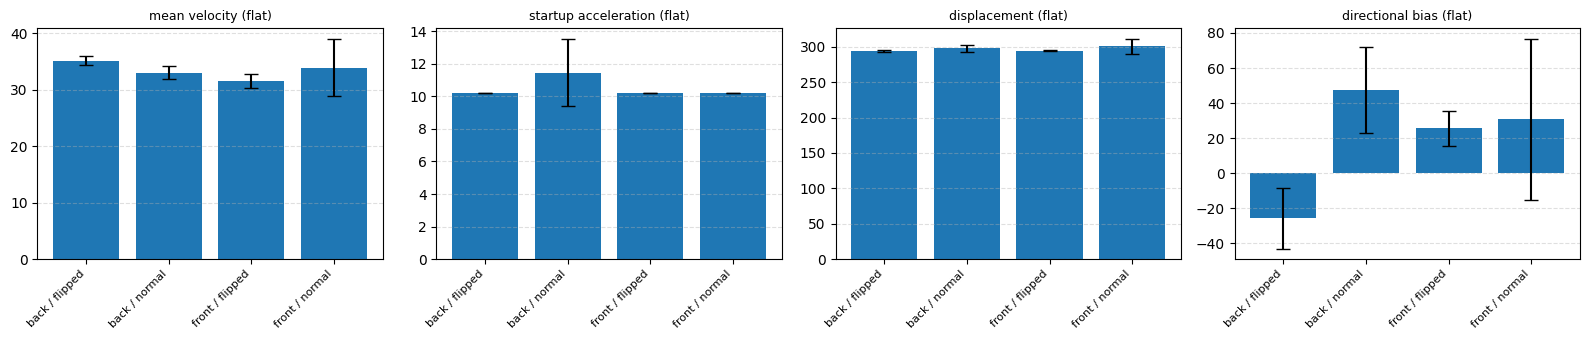

In [12]:
# bar plots for flat condition

flat_summary = grouped_summary_flat.copy()
flat_summary["config"] = (
    flat_summary["position"].astype(str)
    + " / "
    + flat_summary["orientation"].astype(str)
)

config_order = flat_summary["config"].tolist()
x = np.arange(len(config_order))
n_features = len(feature_specs)

fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 3.5), sharey=False)

if n_features == 1:
    axes = [axes]

for ax, (mean_col, std_col, label) in zip(axes, feature_specs):
    means = flat_summary.set_index("config")[mean_col].reindex(config_order)
    stds = flat_summary.set_index("config")[std_col].reindex(config_order)

    ax.bar(x, means.values, yerr=stds.values, capsize=5)
    ax.set_xticks(x)
    ax.set_xticklabels(config_order, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{label} (flat)", fontsize=9)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

<h3>4.2. Summarize Incline Trials and Visualize<a id="4.2"></a></h3>

In [13]:
# summary statistics for incline trials

incline_feat = features_df[features_df["condition"] == "incline"].copy()
assert incline_feat.shape[0] > 0, "no incline trials found"

numeric_cols_incline = incline_feat.select_dtypes(include="number").columns

grouped_summary_incline = (
    incline_feat
    .groupby(["position", "orientation"])[numeric_cols_incline]
    .agg(["mean", "std"])
)

grouped_summary_incline.columns = ["_".join(col) for col in grouped_summary_incline.columns]
grouped_summary_incline = grouped_summary_incline.reset_index()

grouped_summary_incline.round(3)

,position,orientation,mean_velocity_mean,mean_velocity_std,std_velocity_mean,std_velocity_std,mean_acceleration_mean,mean_acceleration_std,std_acceleration_mean,std_acceleration_std,startup_acceleration_mean,startup_acceleration_std,displacement_mean,displacement_std,directional_bias_mean,directional_bias_std
0,back,left,14.754,1.134,11.573,0.917,0.017,0.034,2.947,0.348,10.622,1.336,15.983,0.854,-0.221,0.197
1,back,right,20.429,2.741,14.331,1.641,0.030,0.029,2.507,0.367,12.487,3.420,53.189,1.379,-51.204,1.705
2,front,left,15.913,5.413,14.974,2.761,0.008,0.010,2.770,0.357,11.890,2.182,28.638,20.106,16.320,26.289
3,front,right,22.355,1.582,18.151,0.800,0.025,0.031,3.406,0.569,11.045,1.781,55.289,0.305,-52.819,0.278


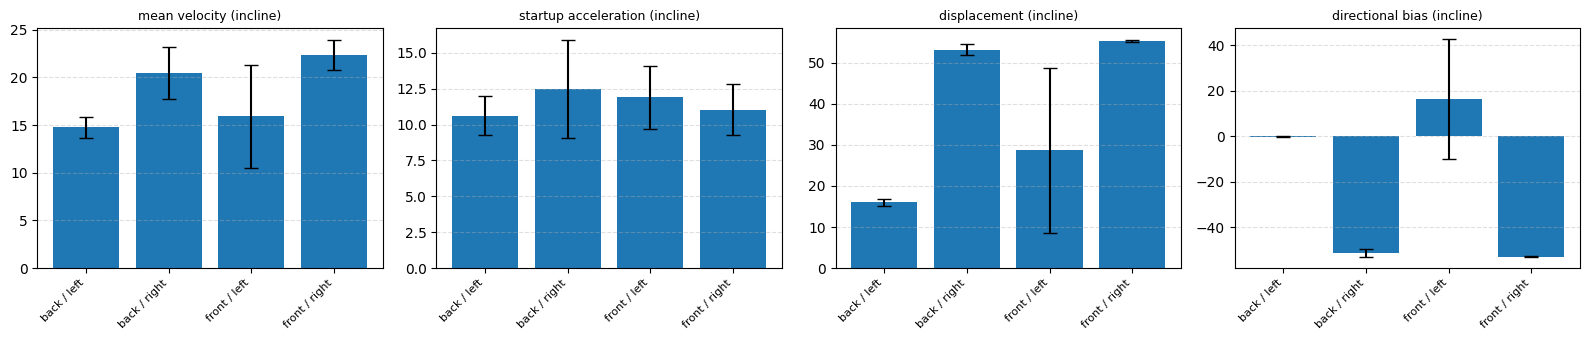

In [14]:
# bar plots for incline condition

incline_summary = grouped_summary_incline.copy()
incline_summary["config"] = (
    incline_summary["position"].astype(str)
    + " / "
    + incline_summary["orientation"].astype(str)
)

config_order = incline_summary["config"].tolist()
x = np.arange(len(config_order))
n_features = len(feature_specs)

fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 3.5), sharey=False)

if n_features == 1:
    axes = [axes]

for ax, (mean_col, std_col, label) in zip(axes, feature_specs):
    means = incline_summary.set_index("config")[mean_col].reindex(config_order)
    stds = incline_summary.set_index("config")[std_col].reindex(config_order)

    ax.bar(x, means.values, yerr=stds.values, capsize=5)
    ax.set_xticks(x)
    ax.set_xticklabels(config_order, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{label} (incline)", fontsize=9)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

<h1>5. Conclusion <a id="5"></a></h1>

<p style="font-size:18px; line-height:1.6;">
This notebook reconstructs the full analysis pipeline used in the SEU rolling-robot experiments.
It converts raw video recordings into structured trajectories, computes trial-level features, and
produces the summary datasets used for further analysis in the thesis.
</p>

<ul style="font-size:18px; line-height:1.6; margin-left:20px;">
    <li><code>data/trajectories/all_trials.csv</code> — reconstructed trajectories for all runs</li>
    <li><code>data/features/features.csv</code> — quantitative features extracted per trial</li>
    <li><code>group_summary_flat</code> and <code>group_summary_incline</code> — aggregated metrics by configuration</li>
</ul>

<p style="font-size:18px; line-height:1.6;">
These outputs form the basis for the statistical and interpretive analyses presented in the main thesis document.
</p>
